In [ ]:
%pip install wfdb

In [ ]:
import wfdb
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, filtfilt, convolve, fftconvolve

# Análise Exploratória

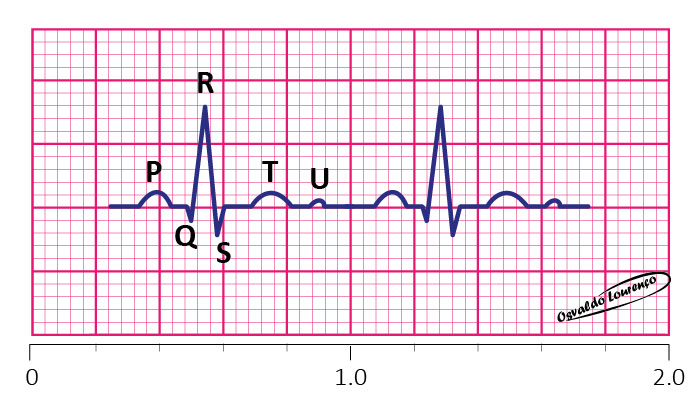

- Onda P: Representa a despolarização atrial, ou seja, a contração dos átrios.
- Complexo QRS: Representa a despolarização ventricular, ou seja, a contração dos ventrículos. É a onda mais proeminente e indica a atividade elétrica mais forte do coração.
- Onda T: Representa a repolarização ventricular, ou seja, o relaxamento dos ventrículos após a contração. Este é um processo crucial para preparar o coração para o próximo batimento.

In [ ]:
drive_path = "./PSD-Trabalho"

if not os.path.exists(drive_path):
    os.makedirs(drive_path)
    print(f"Pasta criada em: {drive_path}")
else:
    print(f"A pasta já existe em: {drive_path}")

In [ ]:
record = wfdb.rdrecord(os.path.join(drive_path, '200'))

signal = record.p_signal[:, 0]
fs = record.fs
tempo = np.arange(len(signal)) / fs

# Plot Sinal Original

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(tempo[:fs*2], signal[:fs*2])

plt.title("ECG Original")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()

plt.show()

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(tempo[:fs*2], signal_fir[:fs*2])

plt.title("ECG após Filtro FIR")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()

plt.show()

In [ ]:
import wfdb
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, filtfilt, convolve, fftconvolve

# Carregar ECG
record = wfdb.rdrecord(os.path.join(drive_path, '200'))

signal = record.p_signal[:, 0]
fs = record.fs
tempo = np.arange(len(signal)) / fs

# Sinal Original
plt.figure(figsize=(15,5))
plt.plot(tempo[:fs*2], signal[:fs*2])
plt.title("1. ECG Original")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()
plt.show()


# Filtro FIR
def fir_bandpass(signal, fs, low=0.5, high=45, numtaps=101):
    nyq = fs / 2
    taps = firwin(numtaps, [low/nyq, high/nyq], pass_zero=False)
    filtered = filtfilt(taps, [1.0], signal)
    return filtered, taps

signal_fir, taps = fir_bandpass(signal, fs)

plt.figure(figsize=(15,5))
plt.plot(tempo[:fs*2], signal_fir[:fs*2])
plt.title("2. ECG após Filtro FIR (Bandpass 0.5–45 Hz)")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()
plt.show()


# Convolução - Tempo
conv_time = convolve(signal, taps, mode='same')

plt.figure(figsize=(15,5))
plt.plot(tempo[:fs*2], conv_time[:fs*2])
plt.title("3. Convolução no Domínio do Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


# Convolução - FFT
conv_fft = fftconvolve(signal, taps, mode='same')

plt.figure(figsize=(15,5))
plt.plot(tempo[:fs*2], conv_fft[:fs*2])
plt.title("4. Convolução via FFT")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


# Filtro de Gabor
def gabor_kernel(fs, f=10, sigma=0.05):
    t = np.linspace(-0.2, 0.2, int(fs*0.4))
    gauss = np.exp(-t**2 / (2*sigma**2))
    wave = np.cos(2 * np.pi * f * t)
    return gauss * wave

kernel = gabor_kernel(fs, f=10, sigma=0.05)

gabor_response = fftconvolve(signal_fir, kernel, mode='same')

plt.figure(figsize=(15,5))
plt.plot(tempo[:fs*2], gabor_response[:fs*2])
plt.title("5. Resposta do Filtro de Gabor")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()